In [ ]:
import os
# import h5py
import cv2
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import scienceplots
plt.style.use(['science', 'notebook', 'grid'])

from scipy.ndimage import gaussian_filter
from skimage import measure
import itertools
from sklearn.cluster import KMeans
from pathlib import Path

from TherMIFASOL.core.variables.GlobalVariables import (
    LAMBDA_NIR, T_SOLIDUS, T_LIQUIDUS, LINES_CRED, COLUMNS_CRED, FAC
)
from TherMIFASOL.core.data_processing.PYROMETER_functions import (
    collect_data_pyrometer,
)
from TherMIFASOL.core.data_processing.CRED_functions import (
    load_cred_array, dl_to_thermo
)
from TherMIFASOL.core.data_processing.XIMEA_functions import (
    load_full_frame_nir, xiq_dl_to_flux_two_table, split_channel,
    xiq_bichromatic_temperature_field, xiq_emissivity_field, 
    apply_homographic_transformation
)
from TherMIFASOL.core.utils.visualization import (
    setup_contour_parameters
)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


In [14]:
PATH_DATA = "/media/dolle/Extreme SSD/DATA_MIFASOL/"
# Work path project
try:
    BASE_DIR = Path(__file__).resolve().parents[3]
except NameError:
    BASE_DIR = Path().resolve().parents[3]


# Path to data
#-------------------
data_path = os.path.join(
    PATH_DATA, "experiences/AddMultiSpectral/MUR2//"
)



# Calibration tables
#-------------------

#   CRED:
array_nuc = np.load(
    os.path.join(
        BASE_DIR, "TherMIFASOL/resources/tables/NUC/NUC_2pts_Temp550_WithNeutralDensity.npy"
        )
    )
array_calibration = np.load(
    os.path.join(
        BASE_DIR, "TherMIFASOL/resources/tables/FLUX/FLUX_IT40_deg1_NUC2.npy"
        )
    )

#   XIMEA:
XIMEA_NUC_table = np.load(
    os.path.join(BASE_DIR, "TherMIFASOL/resources/tables/XIMEA_TRAVAIL_EMMANUEL/nuc_NUC_LURPA.npy")
)

# Flux: IT3 --> 102 µs"
XIMEA_flux_table_Poly1 = np.load(
    os.path.join(BASE_DIR, "TherMIFASOL/resources/tables/XIMEA_TRAVAIL_EMMANUEL/table_flux_IT3_afterNUC1.npy")
)  ## Poly1: Linear flux/DL relationship ---> extrapolation
XIMEA_flux_table_Poly5 = np.load(
    os.path.join(BASE_DIR, "TherMIFASOL/resources/tables/XIMEA_TRAVAIL_EMMANUEL/table_flux_IT3_afterNUC5.npy")
)  ## Poly5: flux/DL relationship ---> interpolation
Low_limit_for_switch = np.load(
    os.path.join(BASE_DIR, "TherMIFASOL/resources/tables/XIMEA_TRAVAIL_EMMANUEL/LimiteBASSE_DL.npy")
)  # Limit for switching to interpolate side to extrapolate side


# Saving path
#------------
saving_path = os.path.join(BASE_DIR, "results/BoardFilter/WagnerLaw")

## Tools

### Loading homographic matrices
* matrix_H is a dictionary whose key is the channel identifier.
* matrix_H[channel] is a 3x3 matrix for the transformation.

In [24]:
with open(os.path.join(
    BASE_DIR, "TherMIFASOL/resources/tables/homographic_matrix/H_matrix.pkl"
), 'rb') as f:
    matrix_H = pickle.load(f)

### Pyrometer position mask
Mask of the pixels in the pyro's viewing area relative to the pyro's field of view (see png ./position_pyro/spot_pyro_spot.png).

In [25]:
mask_position_pyrometer = np.load(os.path.join(
    BASE_DIR, "TherMIFASOL/resources/tables/position_pyrometer/position_pyro_640x512.npy"
    )
)
RGBA_mask_position_pyrometer = np.zeros((512, 640, 4))
RGBA_mask_position_pyrometer[mask_position_pyrometer] = [1, 0, 0, 1] 

## preliminary analysis of channel combinations

### Global overview of channels

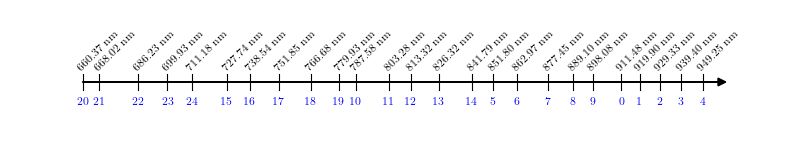

In [7]:
# Sort wavelength and get the corresponding indexes
sorted_indexes = np.argsort(LAMBDA_NIR)
sorted_lambda = LAMBDA_NIR[sorted_indexes]

# Plot
fig, ax = plt.subplots(figsize=(10, 2))
ax.set_xlim(0, 1)
ax.set_ylim(-0.5, 0.5)
ax.axis("off")
x_positions = (sorted_lambda - np.min(sorted_lambda)) / (np.max(sorted_lambda) - np.min(sorted_lambda)) * 0.8 + 0.1

# Draw arrow
ax.arrow(0.1, 0, 0.82, 0, head_width=0.05, head_length=0.01, fc='black', ec='black')

# Placing wavelength
n = len(sorted_lambda)
for i, (x, idx) in enumerate(zip(x_positions, sorted_indexes)):
    ax.plot([x, x], [-0.05, 0.05], color='black', linewidth=0.8)  # Trait vertical
    ax.text(x, -0.15, f"{idx}", ha='center', fontsize=8, color='blue')
    ax.text(x+0.02, 0.07, f"{sorted_lambda[i]*1e9:.2f} nm", ha='center', fontsize=8, rotation=45)

# Display
# plt.savefig("wavelength_distribution.png", bbox_inches='tight', dpi=300)
plt.show()

### Clustering wavelength

In [8]:
pairs = list(itertools.combinations(range(len(sorted_lambda)), 2))
tuple_couple_distance = [(i, j, abs(sorted_lambda[i] - sorted_lambda[j])) for i, j in pairs]
tuple_couple_distance_sorted = sorted(tuple_couple_distance, key=lambda x: x[2])

# Calculating the distances between all possible pairs
distances = np.array([abs(sorted_lambda[i] - sorted_lambda[j]) for i, j in pairs]).reshape(-1, 1)

# Set the number of cluster
K = 5
kmeans = KMeans(n_clusters=K, random_state=0, n_init=10)
labels = kmeans.fit_predict(distances)

# Group distance according to clusterisation
groupes = {i: [] for i in range(K)}
for (idx, d) in enumerate(distances):
    groupes[labels[idx]].append(tuple_couple_distance[idx])


# Sort group by mean value ascending
groups_mean = []
for group_id, group in groupes.items():
    if len(group) == 0:
        continue  # Ignore empty groups

    batch_distances = np.array([d[2] for d in group])
    mean_value = np.mean(batch_distances)
    
    # Add mean and index of the group
    groups_mean.append((group_id, mean_value, group))

groups_mean.sort(key=lambda x: x[1])


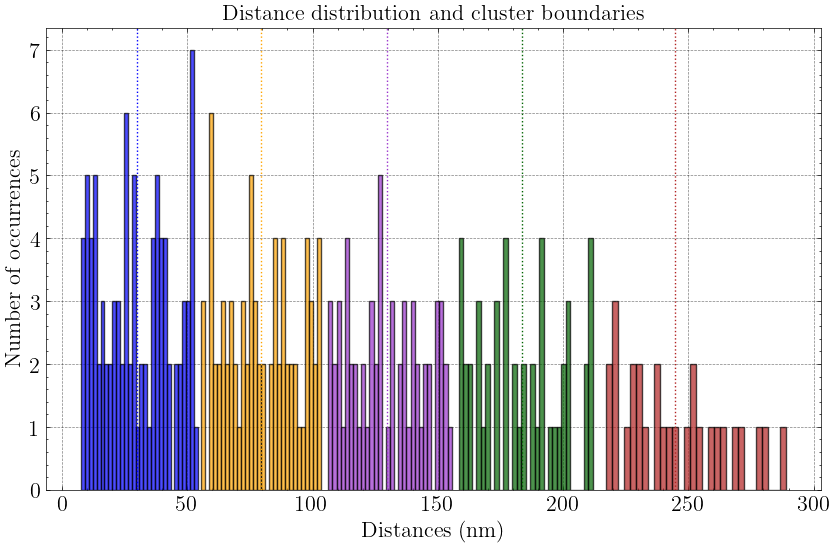

0 - count: 91 - center: 29.82
1 - count: 47 - center: 183.51
2 - count: 74 - center: 79.38
3 - count: 28 - center: 244.78
4 - count: 60 - center: 129.58


In [9]:
color_list = ['blue', 'darkgreen', 'orange', 'firebrick', 'darkorchid']

plt.figure(figsize=(10, 6))

for i in range(K):
    cluster_distances = np.array([d[2]*1e9 for d in groupes[i]])
    plt.hist(cluster_distances, bins=30, alpha=0.7, color=color_list[i], edgecolor='black')

# Affichage des centres des clusters
for i in range(K):
    plt.axvline(kmeans.cluster_centers_[i][0]*1e9, linestyle="dotted", color=color_list[i])

# Ajouter des étiquettes et un titre
plt.xlabel("Distances (nm)")
plt.ylabel("Number of occurrences")
plt.title("Distance distribution and cluster boundaries")
# plt.legend()
# plt.savefig("clustering_distances.png", bbox_inches='tight', dpi=300)
plt.show()

# Résumé des groupes
for i, val in groupes.items():
    print(f"{i} - count: {len(val)} - center: {kmeans.cluster_centers_[i][0]*1e9:.2f}")

In [10]:
channel_partition = {}
for new_id, (group_id, mean_value, group) in enumerate(groups_mean):
    batch_distances = np.array([d[2] for d in group])
    
    stats = {
        "size": len(batch_distances),
        "mean": mean_value,
        "median": np.median(batch_distances),
        "q1": np.percentile(batch_distances, 25),
        "q3": np.percentile(batch_distances, 75),
        "std": np.std(batch_distances),
        "min": np.min(batch_distances),
        "max": np.max(batch_distances)
    }

    channel_partition[f"Groupe {new_id + 1}"] = {
        "elements": group,
        "statistics": stats
    }

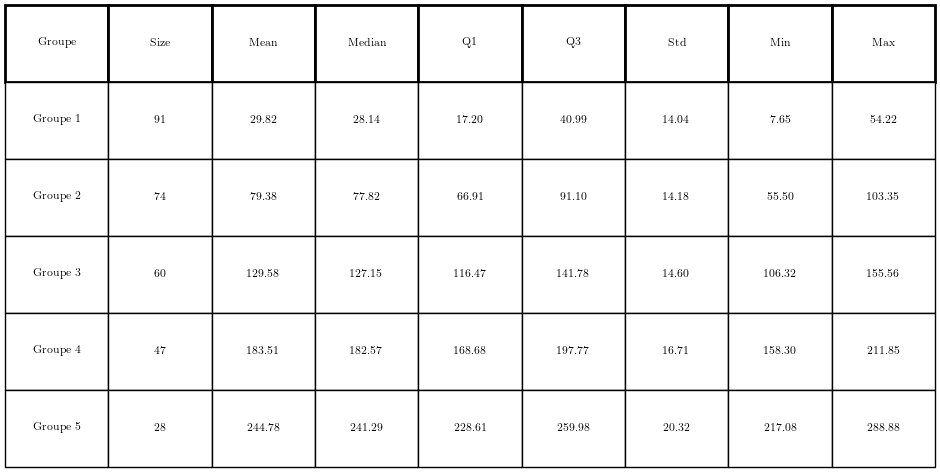

In [11]:
batch_labels = []
batch_statistics = []

for batch_key, batch_data in channel_partition.items():
    batch_labels.append(batch_key)
    batch_statistics.append(batch_data["statistics"])


fig, ax = plt.subplots(figsize=(12, max(6, len(batch_labels) * 0.6)))
ax.axis('off')

table_data = []
columns = ['Groupe', 'Size', 'Mean', 'Median', 'Q1', 'Q3', 'Std', 'Min', 'Max']
m_t_nm = 1e9

for idx, label in enumerate(batch_labels):
    stats = batch_statistics[idx]
    stats_values = [
        f"{stats['size']}",
        f"{stats['mean']*m_t_nm:.2f}",
        f"{stats['median']*m_t_nm:.2f}",
        f"{stats['q1']*m_t_nm:.2f}",
        f"{stats['q3']*m_t_nm:.2f}",
        f"{stats['std']*m_t_nm:.2f}",
        f"{stats['min']*m_t_nm:.2f}",
        f"{stats['max']*m_t_nm:.2f}"
    ]
    table_data.append([label] + stats_values)

table = ax.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='center', bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(8)

for (i, j), cell in table.get_celld().items():
    if j == 0:  # Bold for first column
        cell.set_text_props(weight='bold')
    if i == 0:  # Italic for head of table
        cell.set_text_props(style='italic')
        cell.set_edgecolor('black')
        cell.set_linewidth(2)

# plt.savefig("table_clustering.png", bbox_inches='tight', dpi=300)
plt.show()

## Main study

### Wall description

#### Data recording during cord deposition

Data recording during the deposit of cords from 16 to 30 with 
identifiers from 1 to 16.

```python
f"./MUR2/CRED/CRED_normal_{i:05d}"
f"./MUR2/XIQ/XIQ_normal_{i:05d}"
```
(v : with gas / x : without gas)
| id cordon  | 16  | 17  | 18  | 19  | 20  | 21  | 22  | 23  | 24  | 25  | 26  | 27  | 28  | 29  | 30  |
|------------|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|
| id cam     |  1  |  2  |  3  |  4  |  5  |  7  |  8  |  9  | 10  | 11  | 12  | 13  | 14  | 15  | 16  |
| Argon      |  v  |  v  |  v  |  v  |  v  |  x  |  x  |  x  |  x  |  v  |  v  |  v  |  v  |  v  |  v  |
| Pyrometer  | 16  | 17  | 18  | 19  | 20  | 21  | 22  | 23  | 24  | 25  | 26  | 27  | 28  | 29  | 30  |


Pyrometer profile for all layers from 1 to 30 with identifiers for
43 à 72.
```python
f"./MUR2/pyrometer/H322-14150_{i+42}.r2b"
```


#### Chose the indexes

In [12]:
bead_id_camera = 5  # CAMERA 
bead_id_pyrometer = 20  # Check correspondence table above

### Data time management

In [15]:
# Pyrometer
path_data_bead:str = os.path.join(data_path, f"pyrometer/cordon_{bead_id_pyrometer}.csv")
dict_data_bead:dict = collect_data_pyrometer(csv_path=path_data_bead)

temps_ = dict_data_bead['array time']
temp2C = dict_data_bead['array temp2C']
MAtemp2C = dict_data_bead['array MAtemp2C']
MONeps = dict_data_bead['array MAemissivity']

# CRED
path_data_CRED = os.path.join(data_path, f"CRED/CRED_normal_{bead_id_camera:05d}")
metadata_CRED=pd.read_csv(os.path.join(path_data_CRED, 'metadata.csv'), encoding='unicode_escape', sep=',')
tim_python_CRED=np.asarray(metadata_CRED['t(s)'])
id_im_CRED=np.asarray(metadata_CRED['ImageUniqueID'])

# Multi-spectral
path_data_XIQ = os.path.join(data_path, f"XIQ/XIQ_normal_{bead_id_camera:05d}")
metadata_XIQ=pd.read_csv(os.path.join(path_data_XIQ, 'metadata.csv'), encoding='unicode_escape', sep=',')
tim_python_XIQ=np.asarray(metadata_XIQ['t(s)'])
tim_XIQ=np.asarray(metadata_XIQ['XimeaSec']) + np.asarray(metadata_XIQ['XimeaUSec'])*1e-6 
id_im_XIQ=np.asarray(metadata_XIQ['ImageUniqueID'])

In [16]:
PERC = 0.75  # t = t_start + PERC * duration
duration_recording_data = min(tim_python_XIQ[-1], tim_python_CRED[-1])

# Lowest acquisition frequency for XIMEA : first to manage
ID_XIMEA_img = np.abs(tim_python_XIQ - PERC*duration_recording_data).argmin()
TIME_XIMEA_img = tim_python_XIQ[ID_XIMEA_img]

# Then we took the closest frame from CRED
ID_CRED_img = np.abs(tim_python_CRED - TIME_XIMEA_img).argmin()
TIME_CRED_img = tim_python_CRED[ID_CRED_img]

print(f"Duration recording: {duration_recording_data:.4f} s")
print(f"Percentage selected: {PERC*100} %")
print(f"XIMEA: {TIME_XIMEA_img:.4f} s -- id img: {ID_XIMEA_img:4d}")
print(f" CRED: {TIME_CRED_img:.4f} s -- id img: {ID_CRED_img:4d}")

Duration recording: 10.6265 s
Percentage selected: 75.0 %
XIMEA: 7.9627 s -- id img:  925
 CRED: 7.9620 s -- id img: 2165


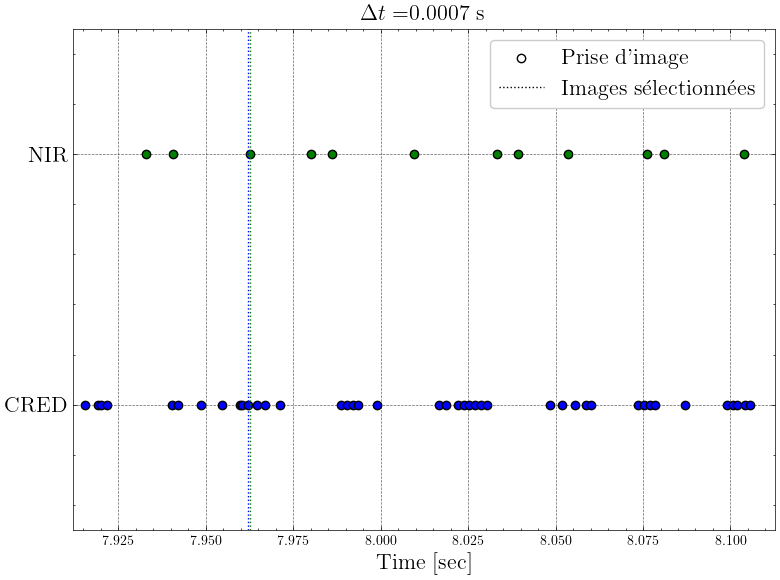

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))

img_prise = [TIME_CRED_img, TIME_XIMEA_img]
extr = 0.05  # Marge pour l'axe X

# FRames chosen
ax.vlines(
    img_prise,
    ymin=-0.5,
    ymax=1.5,
    color=['b', 'g'],
    linestyles='dotted'
)

# Legends
ax.scatter([], [], facecolor='white', edgecolor='black', label="Prise d'image", marker='o')
ax.plot([], [], c='black', label="Images sélectionnées", linestyle='dotted')

# Dots representing frames
ax.scatter(tim_python_CRED, np.zeros(len(tim_python_CRED)), facecolor='blue', edgecolor='black')
ax.scatter(tim_python_XIQ, np.ones(len(tim_python_XIQ)), facecolor='green', edgecolor='black')

# Y-axis corrected
ax.set_yticks([0, 1])
ax.set_yticklabels(['CRED', 'NIR'])

# Setting axes
ax.set_ylim(-0.5, 1.5)
ax.set_xlim(min(img_prise) - extr, max(img_prise) + 3*extr)
ax.tick_params(axis='x', which='major', labelsize=10)
# Legends et labels
ax.legend()
ax.set_xlabel('Time [sec]')
ax.set_title(r"$\Delta t = $" + f"{np.abs(TIME_CRED_img - TIME_XIMEA_img):.4f} s")
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

### Frame management

#### CRED

In [22]:
path_frame_chosen_CRED = os.path.join(
    path_data_CRED, 
    f'{id_im_CRED[ID_CRED_img]:06d}_{tim_python_CRED[ID_CRED_img]:.3f}.npy'
)
CRED_im_dl_raw = load_cred_array(path_frame_chosen_CRED)

CRED_im_thermo = dl_to_thermo(
    dl_raw=CRED_im_dl_raw,
    nuc_table=array_nuc,
    calibration_table=array_calibration,
    emissivity=0.73)


x_iso, y_iso = np.where(
    (CRED_im_thermo > T_SOLIDUS - 5) & (CRED_im_thermo < T_SOLIDUS + 5)
)


#### Ximea

In [26]:
XIMEA_frame_path = os.path.join(
    path_data_XIQ,
    f"{id_im_XIQ[ID_XIMEA_img]:06d}_{tim_python_XIQ[ID_XIMEA_img]:.3f}.npy",
)
# shape: 1088, 2048
XIMEA_im_dl_raw = load_full_frame_nir(
    frame_path=XIMEA_frame_path
    )

# full_frame_NUC_extrapole, full_frame_NUC_flux = ...
# shape: 1088, 2048
XIMEA_im_flux_extrapolate, XIMEA_im_flux_interpolate = xiq_dl_to_flux_two_table(
    full_scale_array=XIMEA_im_dl_raw,
    nuc_table=XIMEA_NUC_table,
    calibration_table_interpolated=XIMEA_flux_table_Poly5,
    calibration_table_extrapolate=XIMEA_flux_table_Poly1
    )


# Split channels --> img[canal, :, :]
# shape: 25, 217, 409
XIMEA_im_flux_extrapolate_split = split_channel(XIMEA_im_flux_extrapolate)

channel_i=0
channel_j=4
# shape: 217, 409
XIMEA_im_thermo = xiq_bichromatic_temperature_field(
    all_channels_split_flux=XIMEA_im_flux_extrapolate_split, 
    channel_i=channel_i, 
    channel_j=channel_j
)

# shape: 217, 409
XIMEA_im_emissivity = xiq_emissivity_field(
    all_channels_split_flux=XIMEA_im_flux_extrapolate_split, 
    channel=channel_i,
    bichromatic_temperature_array=XIMEA_im_thermo
)

# Rescaling 
channel_for_homographic_transformation = 0
XIMEA_im_thermo_rescaled = apply_homographic_transformation(
    array_to_rescale=XIMEA_im_thermo, 
    homographic_matrix=matrix_H[channel_for_homographic_transformation]
)

XIMEA_im_emissivity_rescaled = apply_homographic_transformation(
    array_to_rescale=XIMEA_im_emissivity, 
    homographic_matrix=matrix_H[channel_for_homographic_transformation]
)


### Results

In [27]:
x_contour, y_contour, y_contour_inverted, extent,\
      xtick_pixels, ytick_pixels = setup_contour_parameters(COLUMNS_CRED, LINES_CRED, FAC)

1359.9254136807012
1472.9735110784386


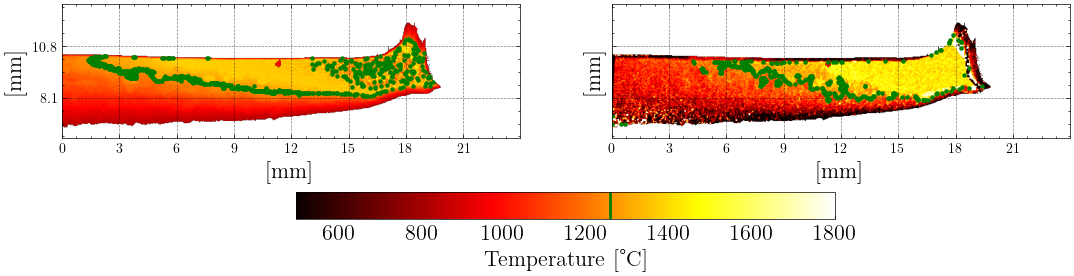

In [28]:
N = 5
mask_shifted = np.roll(mask_position_pyrometer, shift=N, axis=0)
mask_shifted[:N, :] = False  # Set the first rows to False

fake_mask_for_visu = np.nan_to_num(CRED_im_thermo, nan=1100)
fake_mask_for_visu = fake_mask_for_visu <= 1100
CRED_im_thermo_masked = np.ma.masked_where(fake_mask_for_visu, CRED_im_thermo)

XIMEA_im_thermo_rescaled_masked = np.copy(XIMEA_im_thermo_rescaled)
XIMEA_im_thermo_rescaled_masked[fake_mask_for_visu] = np.nan

temp_filled = np.nan_to_num(XIMEA_im_thermo_rescaled_masked, nan=np.nanmean(XIMEA_im_thermo_rescaled_masked))
sigma = 2  # Standard deviation of the Gaussian filter (you can adjust this value)
smoothed_temp = gaussian_filter(temp_filled, sigma=sigma)
smoothed_temp[fake_mask_for_visu] = np.nan

print(np.nanmean(CRED_im_thermo_masked[mask_shifted]) - 273.15)
print(np.nanmean(XIMEA_im_thermo_rescaled_masked[mask_shifted]) - 273.15)

# Isotherm detection
mask_SOL_CRED = (CRED_im_thermo_masked < T_SOLIDUS + 5) & (CRED_im_thermo_masked > T_SOLIDUS - 5)
C_sol_x, C_sol_y = np.where(mask_SOL_CRED)
C_sol_x = LINES_CRED - C_sol_x
mask_LIQ_CRED = (CRED_im_thermo_masked < T_LIQUIDUS + 5) & (CRED_im_thermo_masked > T_LIQUIDUS - 5)
C_liq_x, C_liq_y = np.where(mask_LIQ_CRED)
C_liq_x = LINES_CRED - C_liq_x

mask_SOL_XIMEA = (smoothed_temp < T_SOLIDUS + 5) & (smoothed_temp > T_SOLIDUS - 5)
X_sol_x, X_sol_y = np.where(mask_SOL_XIMEA)
X_sol_x = LINES_CRED - X_sol_x
mask_LIQ_XIMEA = (smoothed_temp < T_LIQUIDUS + 5) & (smoothed_temp > T_LIQUIDUS - 5)
X_liq_x, X_liq_y = np.where(mask_LIQ_XIMEA)
X_liq_x = LINES_CRED - X_liq_x

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 7), sharey=True)

im1 = ax1.imshow(CRED_im_thermo_masked - 273.15, extent=extent, cmap='hot', vmin=500, vmax=1800)
ax1.imshow(RGBA_mask_position_pyrometer, extent=extent)
ax1.scatter(C_sol_y*FAC, C_sol_x*FAC, c='g', s=5)

# Second image (XIMEA)
im2 = ax2.imshow(XIMEA_im_thermo_rescaled_masked - 273.15, extent=extent, cmap='hot', vmin=500, vmax=1800)
ax2.imshow(RGBA_mask_position_pyrometer, extent=extent)
ax2.scatter(X_sol_y*FAC, X_sol_x*FAC, c='g', s=5)


for ax in [ax1, ax2]:
    ax.set_xticks(xtick_pixels * FAC)
    ax.set_yticks(ytick_pixels * FAC)
    ax.set_xticklabels([f"{x:.0f}" for x in xtick_pixels * FAC])
    ax.set_yticklabels([f"{y:.1f}" for y in ytick_pixels * FAC])

    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.set_ylim(ymin=6, ymax=13)
    ax.set_xlabel('[mm]')
    ax.set_ylabel('[mm]')


# Create a single colorbar for the entire figure
cbar = fig.colorbar(im1, ax=[ax1, ax2], orientation='horizontal', shrink=0.9, fraction=0.05, pad=0.1)
cbar.set_label("Temperature [°C]")
cbar.ax.axvline(T_SOLIDUS - 273.15, color='g', linewidth=2)

# Automatic layout adjustment
# fig.tight_layout()
plt.show()


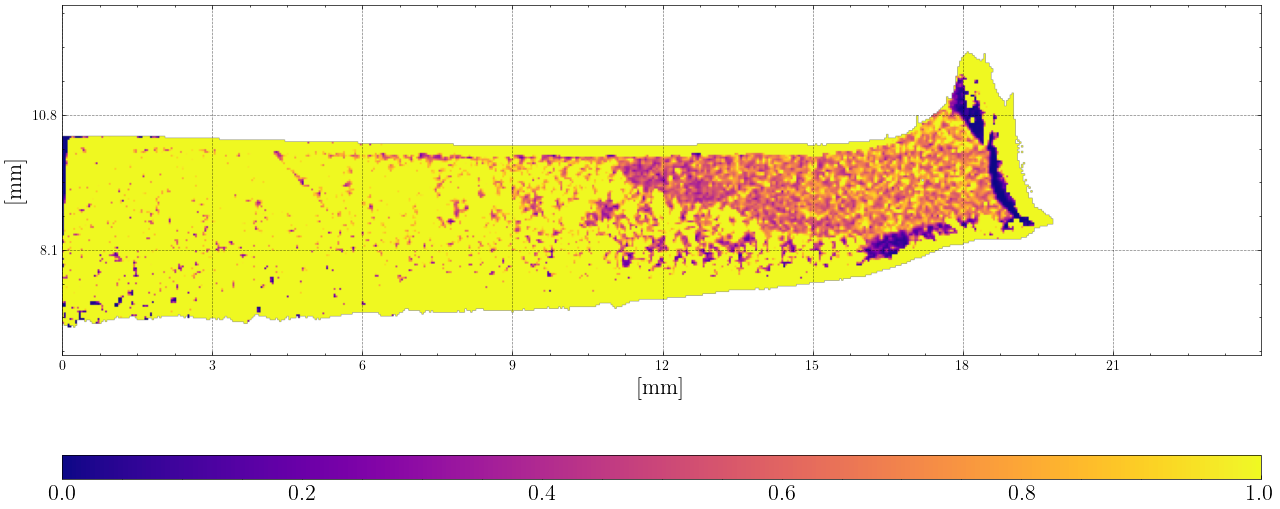

In [29]:
masked_XIMEA_im_emissivity_rescaled = np.ma.masked_where(fake_mask_for_visu, XIMEA_im_emissivity_rescaled)
# masked_XIMEA_im_emissivity_rescaled[temp_CRED.mask]=np.nan

# Champs d'émissivité XIMEA
fig, ax = plt.subplots(1, 1, figsize=(13,7))

im1 = ax.imshow(masked_XIMEA_im_emissivity_rescaled, cmap='plasma', extent=extent, vmin=0, vmax=1)
#im1_bis = ax.imshow(overlay)
cbar.set_label("Emissivity")
fig.colorbar(im1, orientation='horizontal', shrink=1, aspect=50, pad=0.15)

ax.set_xticks(xtick_pixels * FAC)
ax.set_yticks(ytick_pixels * FAC)
ax.set_xticklabels([f"{x:.0f}" for x in xtick_pixels * FAC])
ax.set_yticklabels([f"{y:.1f}" for y in ytick_pixels * FAC])

# Axis labels and limits
ax.set_xlabel('[mm]')
ax.set_ylabel('[mm]')
ax.set_ylim(ymin=6, ymax=13)

ax.tick_params(axis='both', which='major', labelsize=10)
fig.tight_layout()
# plt.savefig("./emissivity_field_bichro.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

61379.35179080056


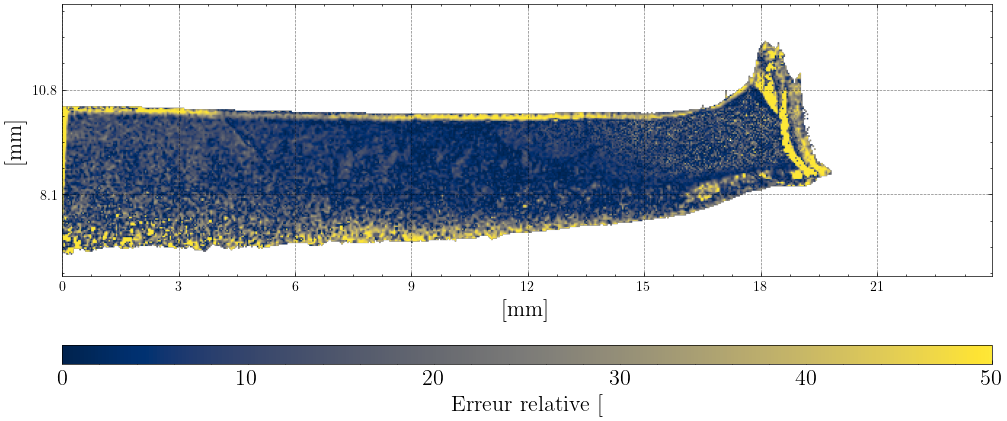

In [30]:

fig, ax = plt.subplots(figsize=(12, 6))

IMAGE = 100*np.abs(CRED_im_thermo_masked - XIMEA_im_thermo_rescaled_masked)/CRED_im_thermo_masked
print(np.nanmax(IMAGE))

# Affichage de l'image
image = ax.imshow(IMAGE, extent=extent, vmin=0, vmax=50, cmap='cividis')

# Axis
ax.set_xticks(xtick_pixels * FAC)
ax.set_yticks(ytick_pixels * FAC)
ax.set_xticklabels([f"{x:.0f}" for x in xtick_pixels * FAC])
ax.set_yticklabels([f"{y:.1f}" for y in ytick_pixels * FAC])
ax.set_xlabel('[mm]')
ax.set_ylabel('[mm]')
ax.tick_params(axis='both', which='major', labelsize=10)
ax.set_ylim(ymin=6, ymax=13)

# Colorbar
cbar = fig.colorbar(image, orientation='horizontal', shrink=1, aspect=50, pad=0.15)
cbar.set_label('Erreur relative [%]')


# plt.savefig("../resultats/erreur_relative_first_order.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

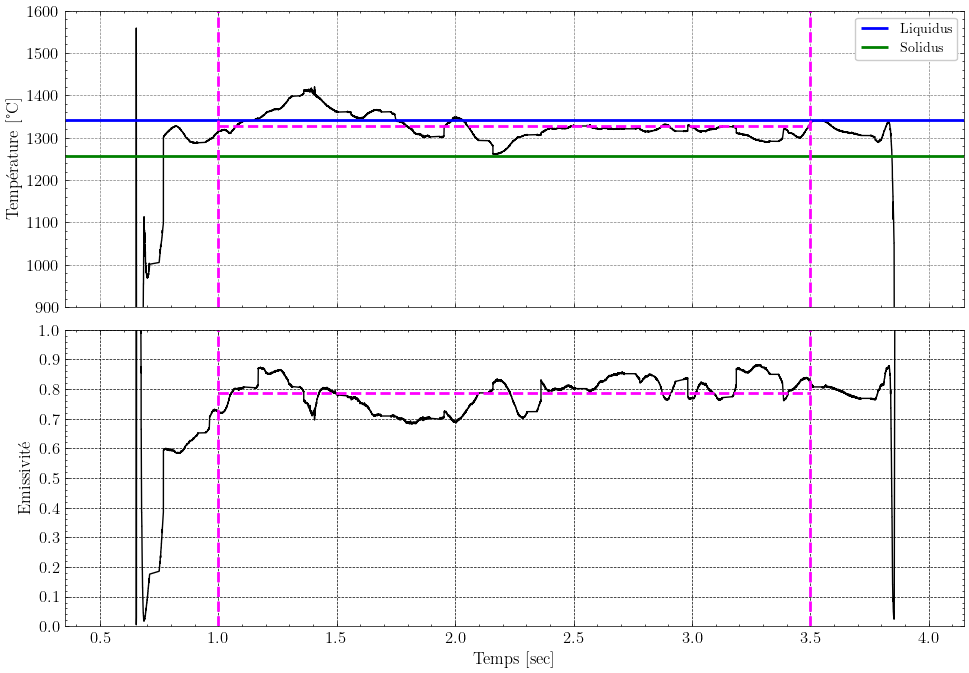

temp moyen: 1328.05$\pm$29.79 °C
emi moyen: 0.79$\pm$0.05 °C


In [31]:
t_start = 0.5
t_end = 4
t_mean_start = 1
t_mean_end = 3.5

mask_time = (temps_ > t_start) & (temps_ < t_end)
time_graph = temps_[mask_time]
temp_graph = MAtemp2C[mask_time]
emi_graph = MONeps[mask_time]

eps_m = np.mean(MONeps[(temps_ > t_mean_start) & (temps_ < t_mean_end)])
eps_std = np.std(MONeps[(temps_ > t_mean_start) & (temps_ < t_mean_end)])

temp_m = np.mean(MAtemp2C[(temps_ > t_mean_start) & (temps_ < t_mean_end)])
temp_std = np.std(MAtemp2C[(temps_ > t_mean_start) & (temps_ < t_mean_end)])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,7), sharex=True)

# Emissivité
#ax1.plot(temps_, temp2C, label=f'Constructeur', lw=1, c='r')
ax1.plot(time_graph, temp_graph, c='k', lw=1)

ax1.hlines(xmin=0.35, xmax=4.15, y=T_LIQUIDUS-273.15, ls='-',color="blue", lw=2, alpha=1, label='Liquidus')
ax1.hlines(xmin=0.35, xmax=4.15, y=T_SOLIDUS-273.15, ls='-',color="green", lw=2, alpha=1, label='Solidus')
ax1.hlines(xmin=t_mean_start, xmax=t_mean_end, y=temp_m, ls='--', color="magenta", lw=2, alpha=1)
ax1.set_ylabel('Température [°C]', fontsize=12)
#ax1.legend()
ax1.set_ylim(900, 1600)
ax1.vlines(ymin=900, ymax=1600, x=[t_mean_start, t_mean_end], ls='--', color="magenta", lw=2, alpha=1)
#ax1.set_xlim(temps_[0], temps_[-1])
#ax1.set_xlim(239.3, temps_[-1])
ax1.legend(shadow=False, fancybox=True, fontsize=10)

# Emissivité
#ax2.plot(temps_, eps, lw=1, c='r', label=f'Constructeur')
ax2.plot(time_graph, emi_graph, c='k', lw=1)
ax2.hlines(xmin=t_mean_start, xmax=t_mean_end, y=eps_m, ls='--', color="magenta", lw=2, alpha=1)
ax2.set_xlabel('Temps [sec]', fontsize=12)
ax2.set_ylabel('Emissivité', fontsize=12)
ax2.set_ylim(0, 1)
ax2.vlines(ymin=0, ymax=1, x=[t_mean_start, t_mean_end], ls='--', color="magenta", lw=2, alpha=1)

major_ticks = np.arange(0, 1.01, 0.1)
minor_ticks = np.arange(0, 1.01, 0.05)
ax2.set_yticks(major_ticks)
#ax2.set_yticks(minor_ticks, minor=True)

ax2.grid(which='minor', alpha=0)
ax2.grid(which='major', alpha=1)

#ax2.legend(shadow=False, fancybox=True, fontsize=10)
fig.tight_layout()

ax1.tick_params(axis='both', which='major', labelsize=12) 
ax2.tick_params(axis='both', which='major', labelsize=12) 
ax2.set_xlim(0.35, 4.15)

# Afficher le graphique
# plt.savefig("./pyro_c20.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

print(f"temp moyen: {temp_m:.2f}" + r"$\pm$" + f"{temp_std:.2f} °C")
print(f"emi moyen: {eps_m:.2f}" + r"$\pm$" + f"{eps_std:.2f} °C")



In [32]:
print(channel_partition.keys())

dict_keys(['Groupe 1', 'Groupe 2', 'Groupe 3', 'Groupe 4', 'Groupe 5'])


In [36]:
import matplotlib
matplotlib.use('Agg')  # Use a non-interactive backend


cpt = 0
No_combination = 300
array_pyrometer_spot_mean_value = np.zeros(shape=(No_combination, 6))

security = False
if not security:

    # Working directory
    total_iteration = sum(len(v["elements"]) for v in channel_partition.values())
    output_dir = "../../../results/AddMultiSpectral/channel_combinations"
    os.makedirs(output_dir, exist_ok=True)

    # Pyrometer
    N = 5
    mask_shifted = np.roll(mask_position_pyrometer, shift=N, axis=0)
    mask_shifted[:N, :] = False  # Set the first rows to False
    print(f"shit {N*FAC} mm downwards")
    x_position_pyrometer = np.mean(np.where(mask_shifted)[1])
    y_position_pyrometer = np.mean(np.where(mask_shifted)[0])
    spot_pyrometer = 0.8/FAC
    new_mask_position_pyrometer = np.zeros((512, 640, 4))
    new_mask_position_pyrometer[mask_shifted] = [0, 0, 0, 1]

    # --- Pre-creation of the main figure to avoid memory saturation ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3))
    im1 = ax1.imshow(np.zeros_like(fake_mask_for_visu, dtype=float), cmap='hot', vmin=500, vmax=2000)
    overlay1 = ax1.imshow(new_mask_position_pyrometer)
    cbar1 = plt.colorbar(im1, ax=ax1, orientation='horizontal', shrink=0.7)
    cbar1.set_label("Temperature [°C]")

    im2 = ax2.imshow(np.zeros_like(fake_mask_for_visu, dtype=float), cmap='plasma', vmin=0, vmax=1)
    overlay2 = ax2.imshow(new_mask_position_pyrometer)
    cbar2 = plt.colorbar(im2, ax=ax2, orientation='horizontal', shrink=0.7)
    cbar2.set_label("Emissivity coefficient")

    ann1 = ax1.annotate("", xy=(0.35, 1.05), xycoords='axes fraction', fontsize=12, verticalalignment='top')
    ann2 = ax2.annotate("", xy=(0.35, 1.05), xycoords='axes fraction', fontsize=12, verticalalignment='top')

    ax1.set_ylim(350, 190)
    ax2.set_ylim(350, 190)

    fig_hist, (ax1_hist, ax2_hist) = plt.subplots(1, 2, figsize=(12, 5))

    with tqdm(total=total_iteration, desc="Traitement des canaux", ncols=100) as pbar:
        for batch_id in channel_partition.keys():

            sub_dir = os.path.join(output_dir, batch_id)
            os.makedirs(sub_dir, exist_ok=True)

            for canal_i, canal_j, distance_ij in channel_partition[batch_id]["elements"]:
                
                # Bichromatic temperature field
                XIMEA_im_thermo = xiq_bichromatic_temperature_field(
                    all_channels_split_flux=XIMEA_im_flux_extrapolate_split, 
                    channel_i=canal_i, 
                    channel_j=canal_j
                )
                # Emissivity field
                XIMEA_im_emissivity = xiq_emissivity_field(
                    all_channels_split_flux=XIMEA_im_flux_extrapolate_split, 
                    channel=canal_i,
                    bichromatic_temperature_array=XIMEA_im_thermo
                )

                # Rescaling 
                channel_for_homographic_transformation = 0
                XIMEA_im_thermo_rescaled = apply_homographic_transformation(
                    array_to_rescale=XIMEA_im_thermo, 
                    homographic_matrix=matrix_H[channel_for_homographic_transformation]
                )
                XIMEA_im_emissivity_rescaled = apply_homographic_transformation(
                    array_to_rescale=XIMEA_im_emissivity, 
                    homographic_matrix=matrix_H[channel_for_homographic_transformation]
                )

                # Isotherms detection
                isotherm_sol = measure.find_contours(np.ma.masked_array(XIMEA_im_thermo_rescaled, fake_mask_for_visu), T_SOLIDUS)
                isotherm_sol_sorted = sorted(isotherm_sol, key=lambda x: len(x), reverse=True)       
                isotherm_liq = measure.find_contours(np.ma.masked_array(XIMEA_im_thermo_rescaled, fake_mask_for_visu), T_LIQUIDUS)
                isotherm_liq_sorted = sorted(isotherm_liq, key=lambda x: len(x), reverse=True)

                # Mean value on the pyrometer spot:
                mean_temp = np.nanmean(XIMEA_im_thermo_rescaled[mask_shifted])
                mean_emi = np.nanmean(XIMEA_im_emissivity_rescaled[mask_shifted])
                array_pyrometer_spot_mean_value[cpt] = [distance_ij, mean_temp, mean_emi, channel_i, channel_j, int(batch_id.split()[1])]
                cpt+=1
                
    
                # --- Update imshow data ---
                im1.set_data(np.ma.masked_array(XIMEA_im_thermo_rescaled, fake_mask_for_visu) - 273.15)
                im2.set_data(np.ma.masked_array(XIMEA_im_emissivity_rescaled, fake_mask_for_visu))

                # --- Update annotations ---
                ann1.set_text(f"Moy: {mean_temp:.0f}°C")
                ann2.set_text(f"Moy: {mean_emi:.2f}")

                # --- Clear previous isotherms only ---
                for line in ax1.lines:
                    line.remove()

                for contour in isotherm_sol_sorted[:1]:
                    mask_values = fake_mask_for_visu[contour[:, 0].astype(int), contour[:, 1].astype(int)]
                    filtered = contour[~mask_values]
                    if len(filtered) > 0:
                        ax1.plot(filtered[:, 1], filtered[:, 0], '.', color='green', markersize=1)
                for contour in isotherm_liq_sorted[:1]:
                    mask_values = fake_mask_for_visu[contour[:, 0].astype(int), contour[:, 1].astype(int)]
                    filtered = contour[~mask_values]
                    if len(filtered) > 0:
                        ax1.plot(filtered[:, 1], filtered[:, 0], '.', color='blue', markersize=1)

                fig.suptitle(
                    f"Canal {canal_i} ({LAMBDA_NIR[canal_i]*1e9:.2f} nm) - Canal {canal_j} ({LAMBDA_NIR[canal_j]*1e9:.2f} nm) | " +
                    r"$\delta \lambda =$" + f"{distance_ij*1e9:.2f} nm"
                )

                img_filename = os.path.join(sub_dir, f"canal_{canal_i}_{canal_j}.png")
                fig.tight_layout()
                fig.savefig(img_filename, dpi=300)

                # --- Histogrammes ---
                temp_values = XIMEA_im_thermo_rescaled[~fake_mask_for_visu] - 273.15
                emissivity_values = XIMEA_im_emissivity_rescaled[~fake_mask_for_visu]

                temp_values = temp_values[(temp_values >= 500) & (temp_values <= 2500)]
                emissivity_values = emissivity_values[(emissivity_values >= 0.2) & (emissivity_values <= 1)]

                ax1_hist.clear()
                ax1_hist.hist(temp_values, bins=50, color='r', alpha=0.7,
                              weights=np.ones_like(temp_values) / len(temp_values))
                ax1_hist.set_title("Temperature distribution")
                ax1_hist.set_xlabel("Temperature [°C]")
                ax1_hist.set_ylabel("Density")
                ax1_hist.set_xlim(500, 2500)
                ax1_hist.set_ylim(0, 1)

                ax2_hist.clear()
                ax2_hist.hist(emissivity_values, bins=50, color='b', alpha=0.7,
                              weights=np.ones_like(emissivity_values) / len(emissivity_values))
                ax2_hist.set_title("Emissivity distribution")
                ax2_hist.set_xlabel("Emissivity")
                ax2_hist.set_ylabel("Density")
                ax2_hist.set_xlim(0, 1)
                ax2_hist.set_ylim(0, 1)

                fig_hist.suptitle(f"Histograms - Channel {canal_i} vs {canal_j}")
                fig_hist.tight_layout()
                hist_filename = os.path.join(sub_dir, f"hist_channel_{canal_i}_{canal_j}.png")
                fig_hist.savefig(hist_filename, dpi=300)

                pbar.set_postfix_str(f"{batch_id} | ch: {canal_i}-{canal_j}")
                pbar.update(1)

    plt.close(fig)
    plt.close(fig_hist)


   


shit 0.1875 mm downwards


Traitement des canaux: 100%|█████████████████| 300/300 [21:18<00:00,  4.26s/it, Groupe 5 | ch: 5-24]


In [37]:
# Define scop limits
Temperature_min, Temperature_max = 500, 2000
Emissivity_min, Emissivity_max = 0, 1

out_of_scope_counts_temperature = {i: 0 for i in range(5)}
out_of_scope_counts_emissivity = {i: 0 for i in range(5)}
for data in array_pyrometer_spot_mean_value:
    distance_ij, mean_temp, mean_emi, channel_i, channel_j, batch_id = data
    if not (Temperature_min <= mean_temp <= Temperature_max):
        out_of_scope_counts_temperature[batch_id] += 1
    if not (Emissivity_min <= mean_emi <= Emissivity_max):
        out_of_scope_counts_emissivity[batch_id] += 1

# Display number of data out of the scope
print(f"Number of values out of temperature scope ({Temperature_min}, {Temperature_max}):")
for batch_id, count in out_of_scope_counts_temperature.items():
    print(f"\tBatch {batch_id}: {count}")
print("\n\n")
print(f"Number of values out of emissivity scope ({Emissivity_min}, {Emissivity_max}):")
for batch_id, count in out_of_scope_counts_emissivity.items():
    print(f"\tBatch {batch_id}: {count}")

# Créer les graphiques
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 8))

# Tracer les données
for batch_id in range(5):
    # Filtrer les données pour le batch_id actuel
    batch_data = array_pyrometer_spot_mean_value[array_pyrometer_spot_mean_value[:, 5] == batch_id]
    ax1.scatter(batch_data[:, 0]*1e9, batch_data[:, 1], color=color_list[batch_id], label=f'Batch {batch_id}')
    ax2.scatter(batch_data[:, 0]*1e9, batch_data[:, 2], color=color_list[batch_id], label=f'Batch {batch_id}')

ax1.hlines(y=1330+273.15, xmin=0, xmax=300, linestyle='--', color='k', label='data pyrometer')
ax2.hlines(y=0.73, xmin=0, xmax=300, linestyle='--', color='k', label='data pyrometer')

# Ajouter des légendes et des labels
fig.suptitle("Mean value of the temperature and emissivity field of the multispectral camera\non the hypothetical pyrometer spot position")
ax1.set_ylim(Temperature_min, Temperature_max)
ax2.set_ylim(Emissivity_min, Emissivity_max+0.1)
ax1.set_ylabel('Temperature [K]')
ax2.set_ylabel('Emissivity')
ax2.set_xlabel('Distance [nm]')
ax1.legend(ncols=2, fontsize=8, loc=4)
ax2.legend(ncols=2, fontsize=8, loc=4)

# Afficher les graphiques
plt.show()

KeyError: np.float64(5.0)

In [ ]:
channel_i_grid, channel_j_grid = np.meshgrid(sorted_lambda*1e9, sorted_lambda*1e9, indexing='ij')

# Initialiser les matrices pour les valeurs moyennes de température et d'émissivité
mean_temp_matrix = np.zeros((len(LAMBDA_NIR), len(LAMBDA_NIR)))
mean_emi_matrix = np.zeros((len(LAMBDA_NIR), len(LAMBDA_NIR)))


# Remplir les matrices avec les valeurs moyennes
for data in array_pyrometer_spot_mean_value:
    _, mean_temp, mean_emi, channel_i, channel_j, _ = data
    mean_temp_matrix[int(channel_i), int(channel_j)] = mean_temp
    mean_emi_matrix[int(channel_i), int(channel_j)] = mean_emi

vmin_temp = mean_temp_matrix[mean_temp_matrix>0].mean() - 3*mean_temp_matrix[mean_temp_matrix>0].std() 
vmax_temp = mean_temp_matrix[mean_temp_matrix>0].mean() + 3*mean_temp_matrix[mean_temp_matrix>0].std()
vmin_emi = np.nanmean(mean_emi_matrix[np.logical_and((mean_emi_matrix>0), (mean_emi_matrix<1))]) - 3*np.nanstd(mean_emi_matrix[np.logical_and((mean_emi_matrix>0), (mean_emi_matrix<1))])
vmax_emi = np.nanmean(mean_emi_matrix[np.logical_and((mean_emi_matrix>0), (mean_emi_matrix<1))]) + 3*np.nanstd(mean_emi_matrix[np.logical_and((mean_emi_matrix>0), (mean_emi_matrix<1))])
print(vmin_temp, vmax_temp)
print(vmin_emi, vmax_emi)

# Créer les graphiques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

# Afficher la température
sc1 = ax1.scatter(channel_i_grid, channel_j_grid, c=mean_temp_matrix, cmap='viridis', vmin=vmin_temp, vmax=vmax_temp)
ax1.set_title('Mean Temperature')
ax1.set_xlabel('Channel i')
ax1.set_ylabel('Channel j')
fig.colorbar(sc1, ax=ax1, label='Temperature', orientation='horizontal')

# Ajouter un second axe x pour les IDs des canaux
ax1_top = ax1.twiny()
ax1_top.set_xlim(ax1.get_xlim())
ax1_top.set_xticks(sorted_lambda * 1e9)
ax1_top.set_xticklabels(sorted_lambda, fontsize=6)
ax1_right = ax1.twinx()
ax1_right.set_ylim(ax1.get_ylim())
ax1_right.set_yticks(sorted_lambda * 1e9)
ax1_right.set_yticklabels(sorted_lambda, fontsize=6)

# Afficher l'émissivité
sc2 = ax2.scatter(channel_i_grid, channel_j_grid, c=mean_emi_matrix, cmap='plasma', vmin=vmin_emi, vmax=vmax_emi)
ax2.set_title('Mean Emissivity')
ax2.set_xlabel('Channel i')
fig.colorbar(sc2, ax=ax2, label='Emissivity', orientation='horizontal')

# Ajouter un second axe x pour les IDs des canaux
ax2_top = ax2.twiny()
ax2_top.set_xlim(ax2.get_xlim())
ax2_top.set_xticks(sorted_lambda * 1e9)
ax2_top.set_xticklabels(sorted_lambda, fontsize=6)

ax2_right = ax2.twinx()
ax2_right.set_ylim(ax2.get_ylim())
ax2_right.set_yticks(sorted_lambda * 1e9)
ax2_right.set_yticklabels(sorted_lambda, fontsize=6)


# Afficher les graphiques
plt.subplots_adjust(wspace=0.25)
plt.show()